In [1]:
import pandas as pd
import numpy as np
import numpy.random as rd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv('titanic.csv')
df

,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,survived
0,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,B5,S,1
1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,C22 C26,S,1
2,1,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,C22 C26,S,0
3,1,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,113781,151.5500,C22 C26,S,0
4,1,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,113781,151.5500,C22 C26,S,0
...,...,...,...,...,...,...,...,...,...,...,...
1304,3,"Zabour, Miss. Hileni",female,14.5000,1,0,2665,14.4542,NaN,C,0
1305,3,"Zabour, Miss. Thamine",female,NaN,1,0,2665,14.4542,NaN,C,0
1306,3,"Zakarian, Mr. Mapriededer",male,26.5000,0,0,2656,7.2250,NaN,C,0
1307,3,"Zakarian, Mr. Ortin",male,27.0000,0,0,2670,7.2250,NaN,C,0


In [3]:
df.columns

Index(['pclass', 'name', 'sex', 'age', 'sibsp', 'parch', 'ticket', 'fare',
       'cabin', 'embarked', 'survived'],
      dtype='object')

In [4]:
df.head(2)

,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,survived
0,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,B5,S,1
1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,C22 C26,S,1


Data cleaning:
1. check for duplicates and remove them
2. check for missing values and hadle/remove them
3. check for invalid dtypes and handle them

In [5]:
df.duplicated().any()

np.False_

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   pclass    1309 non-null   int64  
 1   name      1309 non-null   object 
 2   sex       1309 non-null   object 
 3   age       1046 non-null   float64
 4   sibsp     1309 non-null   int64  
 5   parch     1309 non-null   int64  
 6   ticket    1309 non-null   object 
 7   fare      1308 non-null   float64
 8   cabin     295 non-null    object 
 9   embarked  1307 non-null   object 
 10  survived  1309 non-null   int64  
dtypes: float64(2), int64(4), object(5)
memory usage: 112.6+ KB


Data cleaning columns:
1. age
2. fare
3. cabin
4. embarked


In [7]:
df.isnull().sum()

pclass         0
name           0
sex            0
age          263
sibsp          0
parch          0
ticket         0
fare           1
cabin       1014
embarked       2
survived       0
dtype: int64

In [8]:
df['age'].isnull().sum()

np.int64(263)

In [9]:
df['embarked'].mode() [0]

'S'

In [10]:
emb_md=df['embarked'].mode()[0]
df['embarked']=df['embarked'].fillna(emb_md) 

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   pclass    1309 non-null   int64  
 1   name      1309 non-null   object 
 2   sex       1309 non-null   object 
 3   age       1046 non-null   float64
 4   sibsp     1309 non-null   int64  
 5   parch     1309 non-null   int64  
 6   ticket    1309 non-null   object 
 7   fare      1308 non-null   float64
 8   cabin     295 non-null    object 
 9   embarked  1309 non-null   object 
 10  survived  1309 non-null   int64  
dtypes: float64(2), int64(4), object(5)
memory usage: 112.6+ KB


<Axes: xlabel='age'>

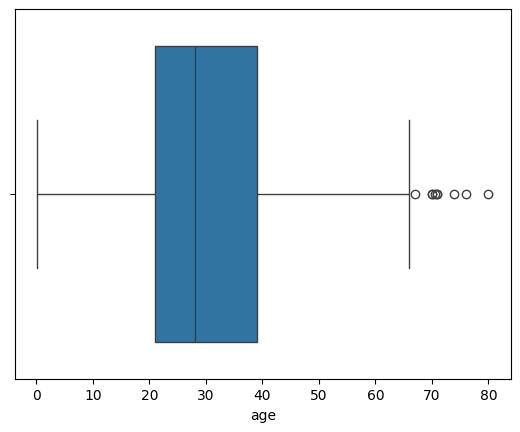

In [12]:
import seaborn as sns
sns.boxplot(df,x='age')

if outlayer is there then take median
if outlayer is not there then use mean

<Axes: xlabel='fare'>

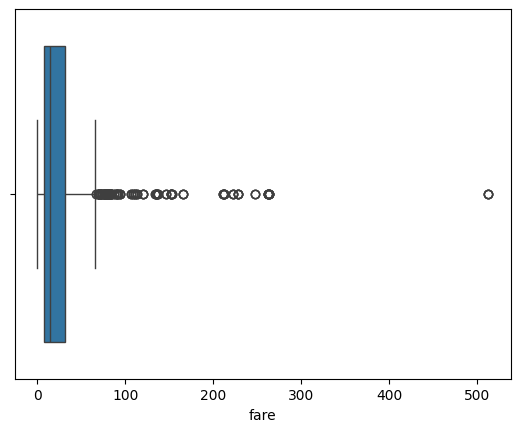

In [13]:
sns.boxplot(df,x='fare')#median

<Axes: xlabel='embarked'>

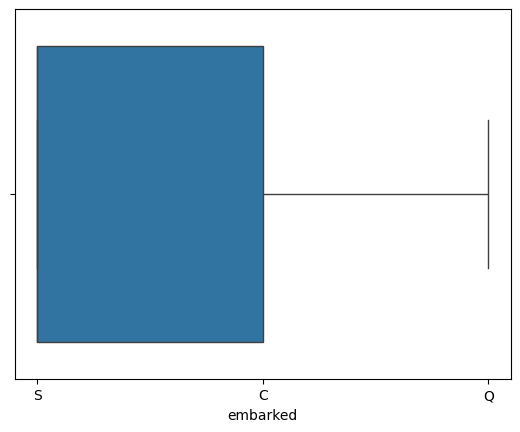

In [14]:
sns.boxplot(df,x='embarked')

In [15]:
emb_md=df['embarked'].mode()[0]
age_med=df['age'].median()
df['age']=df['age'].fillna(age_med)
fare_med=df['fare'].median()
df['fare']=df['fare'].fillna(fare_med)

or

In [16]:
emb_md=df['embarked'].mode()[0]
age_med=df['age'].median()
fare_med=df['fare'].median()

for col,val in zip(['embarked','age','fare'],[emb_md,age_med,fare_med]):
    df[col]=df[col].fillna(val)

by using dropna if u want to drop the col after filling the all values of remaining each and every rows 

In [17]:
df.dropna(axis=1)
df=df.dropna(axis=1)
df

,pclass,name,sex,age,sibsp,parch,ticket,fare,embarked,survived
0,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,S,1
1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,S,1
2,1,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,S,0
3,1,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,113781,151.5500,S,0
4,1,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,113781,151.5500,S,0
...,...,...,...,...,...,...,...,...,...,...
1304,3,"Zabour, Miss. Hileni",female,14.5000,1,0,2665,14.4542,C,0
1305,3,"Zabour, Miss. Thamine",female,28.0000,1,0,2665,14.4542,C,0
1306,3,"Zakarian, Mr. Mapriededer",male,26.5000,0,0,2656,7.2250,C,0
1307,3,"Zakarian, Mr. Ortin",male,27.0000,0,0,2670,7.2250,C,0


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   pclass    1309 non-null   int64  
 1   name      1309 non-null   object 
 2   sex       1309 non-null   object 
 3   age       1309 non-null   float64
 4   sibsp     1309 non-null   int64  
 5   parch     1309 non-null   int64  
 6   ticket    1309 non-null   object 
 7   fare      1309 non-null   float64
 8   embarked  1309 non-null   object 
 9   survived  1309 non-null   int64  
dtypes: float64(2), int64(4), object(4)
memory usage: 102.4+ KB


# Future cleaning

In [19]:
df['sibsp']+df['parch'] 
df['family_cnt']=df['sibsp']+df['parch']       

In [20]:
df=df.drop(columns=['sibsp','parch'])

In [21]:
df=df.sort_values(by='ticket')
df

,pclass,name,sex,age,ticket,fare,embarked,survived,family_cnt
67,1,"Cherry, Miss. Gladys",female,30.0,110152,86.500,S,1,0
245,1,"Rothes, the Countess. of (Lucy Noel Martha Dye...",female,33.0,110152,86.500,S,1,0
195,1,"Maioni, Miss. Roberta",female,16.0,110152,86.500,S,1,0
289,1,"Taussig, Miss. Ruth",female,18.0,110413,79.650,S,1,2
291,1,"Taussig, Mrs. Emil (Tillie Mandelbaum)",female,39.0,110413,79.650,S,1,2
...,...,...,...,...,...,...,...,...,...
63,1,"Chaffee, Mrs. Herbert Fuller (Carrie Constance...",female,47.0,W.E.P. 5734,61.175,S,1,1
62,1,"Chaffee, Mr. Herbert Fuller",male,46.0,W.E.P. 5734,61.175,S,0,1
433,2,"Harris, Mr. Walter",male,30.0,W/C 14208,10.500,S,0,0
81,1,"Crosby, Capt. Edward Gifford",male,70.0,WE/P 5735,71.000,S,0,2


In [22]:
x=df['ticket'].value_counts()
x==1
x[x==1].index
solo=x[x==1].index
solo

Index(['110469', '110489', '110564', '111163', '111240', '111320', '111369',
       '111426', '111427', '113051',
       ...
       'SOTON/OQ 392076', 'SOTON/OQ 3101317', 'SOTON/OQ 3101316',
       'SOTON/O2 3101287', 'SOTON/O2 3101284', 'SOTON/O2 3101272',
       'STON/O2. 3101283', 'STON/O2. 3101282', 'STON/O2. 3101271', '112050'],
      dtype='object', name='ticket', length=713)

In [23]:
df['ticket'].isin(solo)
df.loc[ df['ticket'].isin(solo)]

,pclass,name,sex,age,ticket,fare,embarked,survived,family_cnt
194,1,"Maguire, Mr. John Edward",male,30.0,110469,26.00,S,0,0
34,1,"Borebank, Mr. John James",male,42.0,110489,26.55,S,0,0
29,1,"Bjornstrom-Steffansson, Mr. Mauritz Hakan",male,28.0,110564,26.55,S,1,0
256,1,"Salomon, Mr. Abraham L",male,28.0,111163,26.00,S,1,0
300,1,"Van der hoef, Mr. Wyckoff",male,61.0,111240,33.50,S,0,0
...,...,...,...,...,...,...,...,...,...
523,2,"Oxenham, Mr. Percy Thomas",male,22.0,W./C. 14260,10.50,S,1,0
374,2,"Coleridge, Mr. Reginald Charles",male,29.0,W./C. 14263,10.50,S,0,0
380,2,"Cook, Mrs. (Selena Rogers)",female,22.0,W./C. 14266,10.50,S,1,0
852,3,"Harknett, Miss. Alice Phoebe",female,28.0,W./C. 6609,7.55,S,0,0


In [24]:
def comp_type(row):
    if row['ticket'] in solo:
        return 'solo'
    else:
        if row['family_cnt']==0:
            return 'friends'
        else:
            return 'family'
df['comp_type']=df.apply(comp_type,axis=1)

In [25]:
import numpy as np
a=np.arange(6)
a>2

array([False, False, False,  True,  True,  True])

In [26]:
a[a>2]

array([3, 4, 5])

In [27]:
df['name'].str.split(',')

67                               [Cherry,  Miss. Gladys]
245    [Rothes,  the Countess. of (Lucy Noel Martha D...
195                             [Maioni,  Miss. Roberta]
289                               [Taussig,  Miss. Ruth]
291            [Taussig,  Mrs. Emil (Tillie Mandelbaum)]
                             ...                        
63     [Chaffee,  Mrs. Herbert Fuller (Carrie Constan...
62                        [Chaffee,  Mr. Herbert Fuller]
433                                [Harris,  Mr. Walter]
81                       [Crosby,  Capt. Edward Gifford]
82                            [Crosby,  Miss. Harriet R]
Name: name, Length: 1309, dtype: object

In [28]:
df

,pclass,name,sex,age,ticket,fare,embarked,survived,family_cnt,comp_type
67,1,"Cherry, Miss. Gladys",female,30.0,110152,86.500,S,1,0,friends
245,1,"Rothes, the Countess. of (Lucy Noel Martha Dye...",female,33.0,110152,86.500,S,1,0,friends
195,1,"Maioni, Miss. Roberta",female,16.0,110152,86.500,S,1,0,friends
289,1,"Taussig, Miss. Ruth",female,18.0,110413,79.650,S,1,2,family
291,1,"Taussig, Mrs. Emil (Tillie Mandelbaum)",female,39.0,110413,79.650,S,1,2,family
...,...,...,...,...,...,...,...,...,...,...
63,1,"Chaffee, Mrs. Herbert Fuller (Carrie Constance...",female,47.0,W.E.P. 5734,61.175,S,1,1,family
62,1,"Chaffee, Mr. Herbert Fuller",male,46.0,W.E.P. 5734,61.175,S,0,1,family
433,2,"Harris, Mr. Walter",male,30.0,W/C 14208,10.500,S,0,0,solo
81,1,"Crosby, Capt. Edward Gifford",male,70.0,WE/P 5735,71.000,S,0,2,family


In [29]:
df[['lname','tit_fname']]=df['name'].str.split(',',expand=True)

In [30]:
df['tit_fname'].str.split('.',expand=True)

,0,1,2
67,Miss,Gladys,None
245,the Countess,of (Lucy Noel Martha Dyer-Edwards),None
195,Miss,Roberta,None
289,Miss,Ruth,None
291,Mrs,Emil (Tillie Mandelbaum),None
...,...,...,...
63,Mrs,Herbert Fuller (Carrie Constance Toogood),None
62,Mr,Herbert Fuller,None
433,Mr,Walter,None
81,Capt,Edward Gifford,None


In [31]:
df['tit_fname'].str.split('.',n=1,expand=True)

,0,1
67,Miss,Gladys
245,the Countess,of (Lucy Noel Martha Dyer-Edwards)
195,Miss,Roberta
289,Miss,Ruth
291,Mrs,Emil (Tillie Mandelbaum)
...,...,...
63,Mrs,Herbert Fuller (Carrie Constance Toogood)
62,Mr,Herbert Fuller
433,Mr,Walter
81,Capt,Edward Gifford


In [32]:
df

,pclass,name,sex,age,ticket,fare,embarked,survived,family_cnt,comp_type,lname,tit_fname
67,1,"Cherry, Miss. Gladys",female,30.0,110152,86.500,S,1,0,friends,Cherry,Miss. Gladys
245,1,"Rothes, the Countess. of (Lucy Noel Martha Dye...",female,33.0,110152,86.500,S,1,0,friends,Rothes,the Countess. of (Lucy Noel Martha Dyer-Edwards)
195,1,"Maioni, Miss. Roberta",female,16.0,110152,86.500,S,1,0,friends,Maioni,Miss. Roberta
289,1,"Taussig, Miss. Ruth",female,18.0,110413,79.650,S,1,2,family,Taussig,Miss. Ruth
291,1,"Taussig, Mrs. Emil (Tillie Mandelbaum)",female,39.0,110413,79.650,S,1,2,family,Taussig,Mrs. Emil (Tillie Mandelbaum)
...,...,...,...,...,...,...,...,...,...,...,...,...
63,1,"Chaffee, Mrs. Herbert Fuller (Carrie Constance...",female,47.0,W.E.P. 5734,61.175,S,1,1,family,Chaffee,Mrs. Herbert Fuller (Carrie Constance Toogood)
62,1,"Chaffee, Mr. Herbert Fuller",male,46.0,W.E.P. 5734,61.175,S,0,1,family,Chaffee,Mr. Herbert Fuller
433,2,"Harris, Mr. Walter",male,30.0,W/C 14208,10.500,S,0,0,solo,Harris,Mr. Walter
81,1,"Crosby, Capt. Edward Gifford",male,70.0,WE/P 5735,71.000,S,0,2,family,Crosby,Capt. Edward Gifford


In [33]:
df[['coutesey_title','fname']]=df['tit_fname'].str.split('.',n=1,expand=True)

Strip---> remove the the spaces

In [34]:
for col in ['coutesey_title','fname','lname']:
    df[col]=df[col].str.strip()

In [35]:
df=df.drop(columns=['name','tit_fname'])

In [36]:
df['embarked'].unique()

array(['S', 'C', 'Q'], dtype=object)

In [37]:
df['embarked']=df['embarked'].replace({'S':'Southampton','C':'Cherbourg','Q':'Queenstown'})

In [38]:
df=df.rename(columns={'sex':'gender'})


In [39]:
# def psg_crew(row):
#     if row['fare']==0:
#         return 'crew'
#     else:
#         return 'passenger'
# df['psg/crew']=df.apply(psg_crew,axis=1)
#---------------------------------->
crew_members=df.loc[df['fare']==0]

In [40]:
df.loc[df['fare']==0].index
idx=df.loc[df['fare']==0].index
df=df.drop(index=idx)

In [41]:
df.columns

Index(['pclass', 'gender', 'age', 'ticket', 'fare', 'embarked', 'survived',
       'family_cnt', 'comp_type', 'lname', 'coutesey_title', 'fname'],
      dtype='object')

In [42]:
df

,pclass,gender,age,ticket,fare,embarked,survived,family_cnt,comp_type,lname,coutesey_title,fname
67,1,female,30.0,110152,86.500,Southampton,1,0,friends,Cherry,Miss,Gladys
245,1,female,33.0,110152,86.500,Southampton,1,0,friends,Rothes,the Countess,of (Lucy Noel Martha Dyer-Edwards)
195,1,female,16.0,110152,86.500,Southampton,1,0,friends,Maioni,Miss,Roberta
289,1,female,18.0,110413,79.650,Southampton,1,2,family,Taussig,Miss,Ruth
291,1,female,39.0,110413,79.650,Southampton,1,2,family,Taussig,Mrs,Emil (Tillie Mandelbaum)
...,...,...,...,...,...,...,...,...,...,...,...,...
63,1,female,47.0,W.E.P. 5734,61.175,Southampton,1,1,family,Chaffee,Mrs,Herbert Fuller (Carrie Constance Toogood)
62,1,male,46.0,W.E.P. 5734,61.175,Southampton,0,1,family,Chaffee,Mr,Herbert Fuller
433,2,male,30.0,W/C 14208,10.500,Southampton,0,0,solo,Harris,Mr,Walter
81,1,male,70.0,WE/P 5735,71.000,Southampton,0,2,family,Crosby,Capt,Edward Gifford


In [43]:
pd.cut(df['age'],bins=[0,3,17,31,60,100],labels=['baby','child','teen_age','adults','senior'])
df['age_category']=pd.cut(df['age'],bins=[0,3,17,31,60,100],labels=['baby','child','teen_age','adults','senior'])
df['age_category']

67     teen_age
245      adults
195       child
289    teen_age
291      adults
         ...   
63       adults
62       adults
433    teen_age
81       senior
82       adults
Name: age_category, Length: 1292, dtype: category
Categories (5, object): ['baby' < 'child' < 'teen_age' < 'adults' < 'senior']

In [44]:
list=['ticket','coutesey_title','fname','lname','gender','age','age_category','pclass','family_cnt','comp_type','embarked','fare','survived']
df=df[list]

In [45]:
df=df.reset_index(drop=True)
df
crew_members=crew_members.reset_index(drop=True)

In [46]:
df.loc[df['fare']==0].shape[0]

0

In [47]:
df

,ticket,coutesey_title,fname,lname,gender,age,age_category,pclass,family_cnt,comp_type,embarked,fare,survived
0,110152,Miss,Gladys,Cherry,female,30.0,teen_age,1,0,friends,Southampton,86.500,1
1,110152,the Countess,of (Lucy Noel Martha Dyer-Edwards),Rothes,female,33.0,adults,1,0,friends,Southampton,86.500,1
2,110152,Miss,Roberta,Maioni,female,16.0,child,1,0,friends,Southampton,86.500,1
3,110413,Miss,Ruth,Taussig,female,18.0,teen_age,1,2,family,Southampton,79.650,1
4,110413,Mrs,Emil (Tillie Mandelbaum),Taussig,female,39.0,adults,1,2,family,Southampton,79.650,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1287,W.E.P. 5734,Mrs,Herbert Fuller (Carrie Constance Toogood),Chaffee,female,47.0,adults,1,1,family,Southampton,61.175,1
1288,W.E.P. 5734,Mr,Herbert Fuller,Chaffee,male,46.0,adults,1,1,family,Southampton,61.175,0
1289,W/C 14208,Mr,Walter,Harris,male,30.0,teen_age,2,0,solo,Southampton,10.500,0
1290,WE/P 5735,Capt,Edward Gifford,Crosby,male,70.0,senior,1,2,family,Southampton,71.000,0


In [48]:
df.loc[df['fare']==0]

,ticket,coutesey_title,fname,lname,gender,age,age_category,pclass,family_cnt,comp_type,embarked,fare,survived


In [49]:
df['ticket'].value_counts()

ticket
CA. 2343            11
CA 2144              8
1601                 8
347082               7
347077               7
                    ..
STON/OQ. 369943      1
STON/O2. 3101290     1
STON/O2. 3101283     1
STON/O2. 3101282     1
110489               1
Name: count, Length: 918, dtype: int64

In [50]:
tit_cnt=dict((df['ticket'].value_counts()))
df['no_of_psg']=df['ticket'].map(tit_cnt)
df['fare']=df['fare']/df['no_of_psg']
df=df.drop(columns='no_of_psg')
df

,ticket,coutesey_title,fname,lname,gender,age,age_category,pclass,family_cnt,comp_type,embarked,fare,survived
0,110152,Miss,Gladys,Cherry,female,30.0,teen_age,1,0,friends,Southampton,28.833333,1
1,110152,the Countess,of (Lucy Noel Martha Dyer-Edwards),Rothes,female,33.0,adults,1,0,friends,Southampton,28.833333,1
2,110152,Miss,Roberta,Maioni,female,16.0,child,1,0,friends,Southampton,28.833333,1
3,110413,Miss,Ruth,Taussig,female,18.0,teen_age,1,2,family,Southampton,26.550000,1
4,110413,Mrs,Emil (Tillie Mandelbaum),Taussig,female,39.0,adults,1,2,family,Southampton,26.550000,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1287,W.E.P. 5734,Mrs,Herbert Fuller (Carrie Constance Toogood),Chaffee,female,47.0,adults,1,1,family,Southampton,30.587500,1
1288,W.E.P. 5734,Mr,Herbert Fuller,Chaffee,male,46.0,adults,1,1,family,Southampton,30.587500,0
1289,W/C 14208,Mr,Walter,Harris,male,30.0,teen_age,2,0,solo,Southampton,10.500000,0
1290,WE/P 5735,Capt,Edward Gifford,Crosby,male,70.0,senior,1,2,family,Southampton,35.500000,0


# Data Analysis
Analysis is to find which factors are affecting the servival rate

1. how many passengers(including crew numbers)  are present in the   dataset

In [51]:
# len(df)
# df.shape[0]
crew_members.shape[0]+df.shape[0]

1309

2. how many crew memmbers are present

In [52]:
crew_members.shape[0]

17

3. Find the no.of passengers

In [53]:
df.shape[0]

1292

In [54]:
df.query(" fare==0 ")

,ticket,coutesey_title,fname,lname,gender,age,age_category,pclass,family_cnt,comp_type,embarked,fare,survived


5. get the statistical discription of all the cols

In [55]:
df.describe()

,age,pclass,family_cnt,fare,survived
count,1292.000000,1292.000000,1292.000000,1292.000000,1292.000000
mean,29.468008,2.301084,0.895511,14.951572,0.385449
std,12.953286,0.836743,1.590759,13.532453,0.486890
min,0.166700,1.000000,0.000000,3.170800,0.000000
25%,22.000000,2.000000,0.000000,7.666667,0.000000
50%,28.000000,3.000000,0.000000,8.081250,0.000000
75%,35.000000,3.000000,1.000000,15.045800,1.000000
max,80.000000,3.000000,10.000000,128.082300,1.000000


1. find the number of passenger each gender

observation.male passeger is more  compare than famele passenger

In [56]:
df.groupby(by='gender')
g=df.groupby(by='gender')

In [57]:
g.agg({'gender':'count'})

,gender
gender,
female,466
male,826


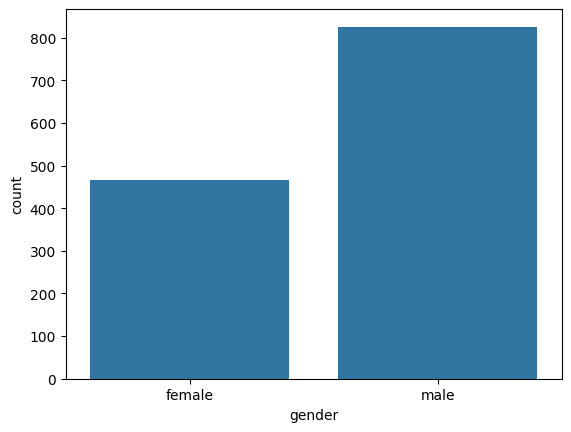

In [58]:
sns.countplot(df,x='gender')
plt.show()

2. find  gender wise total_fare

observation : mae psgs paid more than  female psgs

In [59]:
df.groupby(by='gender').agg({'fare':'sum'})


,fare
gender,
female,7911.282723
male,11406.147927


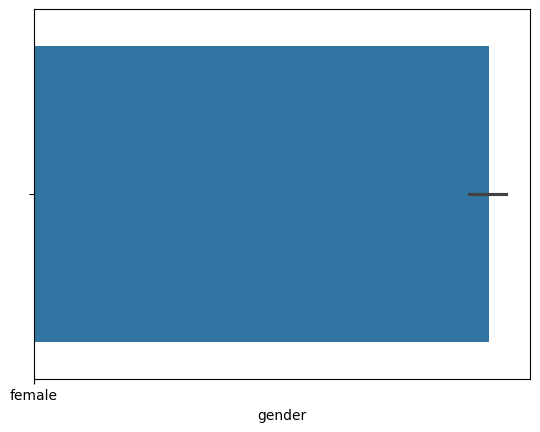

In [60]:
sns.barplot(df,x='gender')
plt.show()

In [61]:
g.agg({'fare':['max','min']})

fare        
             max     min
gender                  
female  128.0823  3.7111
male    128.0823  3.1708

3.find no of psgs in each pclass (Represent in percentage) 
proportion of psgs in each class

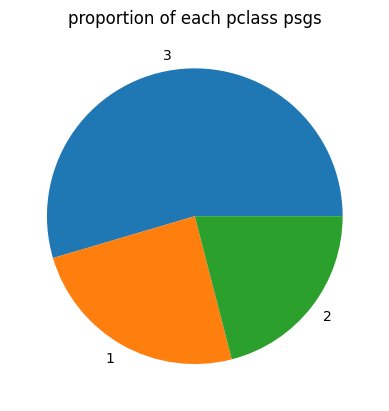

In [62]:
p=df['pclass'].value_counts()
plt.pie(x=p.values,labels=p.index)
plt.title('proportion of each pclass psgs')
plt.show()

observation : more psgs are preffering pclass 3

4.find the pclass and gender wise count and total fare

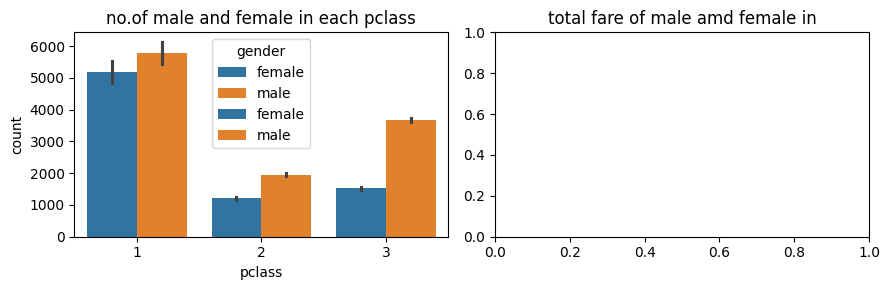

In [63]:
fig,axes=plt.subplots(1,2,figsize=(9,3))
sns.countplot(df,x='pclass',hue='gender',ax=axes[0])
sns.barplot(df,x='pclass',hue='gender',y='fare',estimator='sum',ax=axes[0])
axes[0].set_title('no.of male and female in each pclass')
axes[1].set_title('total fare of male amd female in')
plt.tight_layout()

In [64]:
df

,ticket,coutesey_title,fname,lname,gender,age,age_category,pclass,family_cnt,comp_type,embarked,fare,survived
0,110152,Miss,Gladys,Cherry,female,30.0,teen_age,1,0,friends,Southampton,28.833333,1
1,110152,the Countess,of (Lucy Noel Martha Dyer-Edwards),Rothes,female,33.0,adults,1,0,friends,Southampton,28.833333,1
2,110152,Miss,Roberta,Maioni,female,16.0,child,1,0,friends,Southampton,28.833333,1
3,110413,Miss,Ruth,Taussig,female,18.0,teen_age,1,2,family,Southampton,26.550000,1
4,110413,Mrs,Emil (Tillie Mandelbaum),Taussig,female,39.0,adults,1,2,family,Southampton,26.550000,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1287,W.E.P. 5734,Mrs,Herbert Fuller (Carrie Constance Toogood),Chaffee,female,47.0,adults,1,1,family,Southampton,30.587500,1
1288,W.E.P. 5734,Mr,Herbert Fuller,Chaffee,male,46.0,adults,1,1,family,Southampton,30.587500,0
1289,W/C 14208,Mr,Walter,Harris,male,30.0,teen_age,2,0,solo,Southampton,10.500000,0
1290,WE/P 5735,Capt,Edward Gifford,Crosby,male,70.0,senior,1,2,family,Southampton,35.500000,0


In [65]:
# df[['age','fare']].value_counts()
df.groupby(by=['age_category','pclass']).agg({'age_category':'count','fare':'sum'})

C:\Users\dell\AppData\Local\Temp\ipykernel_15476\2954178864.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(by=['age_category','pclass']).agg({'age_category':'count','fare':'sum'})


age_category         fare
age_category pclass                           
baby         1                  2    50.516667
             2                 13   112.895167
             3                 26   130.950221
child        1                 13   398.096376
             2                 20   201.202067
             3                 80   505.836957
teen_age     1                117  4050.351627
             2                140  1674.571367
             3                475  3637.475757
adults       1                163  5725.639187
             2                 92  1105.643700
             3                118   875.672114
senior       1                 21   728.487743
             2                  6    66.537500
             3                  6    53.554200

obseration:
in pclass 1 ,even  thrugh male count is higher than female,male are paying less
half of the male and females psgs are present in pclass 3
based on pclass  they are paying

In [66]:
df

,ticket,coutesey_title,fname,lname,gender,age,age_category,pclass,family_cnt,comp_type,embarked,fare,survived
0,110152,Miss,Gladys,Cherry,female,30.0,teen_age,1,0,friends,Southampton,28.833333,1
1,110152,the Countess,of (Lucy Noel Martha Dyer-Edwards),Rothes,female,33.0,adults,1,0,friends,Southampton,28.833333,1
2,110152,Miss,Roberta,Maioni,female,16.0,child,1,0,friends,Southampton,28.833333,1
3,110413,Miss,Ruth,Taussig,female,18.0,teen_age,1,2,family,Southampton,26.550000,1
4,110413,Mrs,Emil (Tillie Mandelbaum),Taussig,female,39.0,adults,1,2,family,Southampton,26.550000,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1287,W.E.P. 5734,Mrs,Herbert Fuller (Carrie Constance Toogood),Chaffee,female,47.0,adults,1,1,family,Southampton,30.587500,1
1288,W.E.P. 5734,Mr,Herbert Fuller,Chaffee,male,46.0,adults,1,1,family,Southampton,30.587500,0
1289,W/C 14208,Mr,Walter,Harris,male,30.0,teen_age,2,0,solo,Southampton,10.500000,0
1290,WE/P 5735,Capt,Edward Gifford,Crosby,male,70.0,senior,1,2,family,Southampton,35.500000,0


5. the age_cate wise  no_of_ psgs and total fare in each pclass 


In [67]:
df.groupby(by=['pclass','age_category']).agg({'age_category':'count','fare':'sum'})

C:\Users\dell\AppData\Local\Temp\ipykernel_15476\1055124320.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(by=['pclass','age_category']).agg({'age_category':'count','fare':'sum'})


age_category         fare
pclass age_category                           
1      baby                     2    50.516667
       child                   13   398.096376
       teen_age               117  4050.351627
       adults                 163  5725.639187
       senior                  21   728.487743
2      baby                    13   112.895167
       child                   20   201.202067
       teen_age               140  1674.571367
       adults                  92  1105.643700
       senior                   6    66.537500
3      baby                    26   130.950221
       child                   80   505.836957
       teen_age               475  3637.475757
       adults                 118   875.672114
       senior                   6    53.554200

In [68]:
x=df
pd.pivot_table(df,index=['age_category'],columns=['pclass'],values='fare',aggfunc=['count','sum'])

C:\Users\dell\AppData\Local\Temp\ipykernel_15476\2364948389.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pd.pivot_table(df,index=['age_category'],columns=['pclass'],values='fare',aggfunc=['count','sum'])
C:\Users\dell\AppData\Local\Temp\ipykernel_15476\2364948389.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pd.pivot_table(df,index=['age_category'],columns=['pclass'],values='fare',aggfunc=['count','sum'])


count                    sum                          
pclass           1    2    3            1            2            3
age_category                                                       
baby             2   13   26    50.516667   112.895167   130.950221
child           13   20   80   398.096376   201.202067   505.836957
teen_age       117  140  475  4050.351627  1674.571367  3637.475757
adults         163   92  118  5725.639187  1105.643700   875.672114
senior          21    6    6   728.487743    66.537500    53.554200

obseration: teen_agers are in high in every class
in pclass 1 adults are more
in pclass 2 teen are  more
in pclass 3 teen are more


the age_cate wise  no_of_ psgs and total fare in each pclass and gender

In [69]:
g.agg({'gender':'count','fare':['max','min']})


gender      fare        
        count       max     min
gender                         
female    466  128.0823  3.7111
male      826  128.0823  3.1708

# practice

6. highest and lowest fare in each group

In [70]:
df.groupby('gender').agg({'fare':['max','min']})
pd.pivot_table(df,index=['pclass','gender'],aggfunc=['max','min'],values='fare')

max      min
                   fare     fare
pclass gender                   
1      female  128.0823  15.5000
       male    128.0823   5.0000
2      female   16.0000   5.2500
       male     16.0000   5.2500
3      female   10.5167   3.7111
       male     19.9667   3.1708

observation:in first class both females and males are max in every class males are does't paid comparing female 

7. find the highest and lowest fare paid by male and female in each pclass

In [71]:
pd.pivot_table(df,index=['pclass','gender'],aggfunc=['max','min'],values='fare')

max      min
                   fare     fare
pclass gender                   
1      female  128.0823  15.5000
       male    128.0823   5.0000
2      female   16.0000   5.2500
       male     16.0000   5.2500
3      female   10.5167   3.7111
       male     19.9667   3.1708

Observation:in 1st & 3rd pclass both gender  are paid same fare  and 2nd class highest male payers are there  & in every pclass lowest male payers are there comapre to females 

1. find the highest and lowest fare paid by male and female in each age_category

In [72]:
pd.pivot_table(df,index=['age_category','gender'],aggfunc=['max','min'],values='fare')

C:\Users\dell\AppData\Local\Temp\ipykernel_15476\2508177052.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pd.pivot_table(df,index=['age_category','gender'],aggfunc=['max','min'],values='fare')
C:\Users\dell\AppData\Local\Temp\ipykernel_15476\2508177052.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pd.pivot_table(df,index=['age_category','gender'],aggfunc=['max','min'],values='fare')


max       min
                           fare      fare
age_category gender                      
baby         female   25.258333  3.711100
             male     25.258333  4.215000
child        female   52.834375  4.215000
             male     37.482143  3.170800
teen_age     female   82.506933  3.711100
             male     82.506933  4.012500
adults       female  128.082300  4.467857
             male    128.082300  4.467857
senior       female   55.444800  9.587500
             male     55.444800  6.237500

Observation:Based on age category adults are  paying high fare and child males are  paid low 

find the hifghest and lowest fare paid by male and female in each  pclass and age_category

In [73]:
pd.pivot_table(df,index=['pclass','age_category','gender'],aggfunc=['max','min'],values='fare')

C:\Users\dell\AppData\Local\Temp\ipykernel_15476\4172414619.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pd.pivot_table(df,index=['pclass','age_category','gender'],aggfunc=['max','min'],values='fare')
C:\Users\dell\AppData\Local\Temp\ipykernel_15476\4172414619.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pd.pivot_table(df,index=['pclass','age_category','gender'],aggfunc=['max','min'],values='fare')


max        min
                                  fare       fare
pclass age_category gender                       
1      baby         female   25.258333  25.258333
                    male     25.258333  25.258333
       child        female   52.834375  19.700000
                    male     37.482143  23.550000
       teen_age     female   82.506933  15.500000
                    male     82.506933  15.500000
       adults       female  128.082300  19.700000
                    male    128.082300   5.000000
       senior       female   55.444800  25.986100
                    male     55.444800  26.000000
2      baby         female   10.394800   6.937500
                    male     12.334733   6.250000
       child        female   15.035400   6.937500
                    male     13.000000   5.250000
       teen_age     female   15.000000   6.250000
                    male     15.579200   8.750000
       adults       female   16.000000   5.250000
                    male     16.000000   6.500000
       senior       male     13.000000   9.687500
3      baby         female    6.737500   3.711100
                    male      5.862500   4.215000
       child        female    8.050000   4.215000
                    male      9.500000   3.170800
       teen_age     female   10.516700   3.711100
                    male     19.966700   4.012500
       adults       female    9.587500   4.467857
                    male      9.500000   4.467857
       senior       female    9.587500   9.587500
                    male     14.454200   6.237500

Obseration:in 1st pclass both genders  are paid highest fare  and 2nd and 3rd pclass both are paid lowest fase

# what  factors are affecting the survival rate

practice

In [74]:
#pd.pivot_table(df,values='fare')

In [75]:
pd.pivot_table(df,index='gender',values='fare')

,fare
gender,
female,16.977002
male,13.808896


In [76]:
pd.pivot_table(df,index='gender',aggfunc='sum',values='fare')

,fare
gender,
female,7911.282723
male,11406.147927


In [77]:
pd.pivot_table(df,index=['pclass','gender'],aggfunc='sum',values='fare')

fare
pclass gender             
1      female  5176.173664
       male    5776.917936
2      female  1211.044067
       male    1949.805733
3      female  1524.064992
       male    3679.424258

In [78]:
pd.pivot_table(df,index='pclass',columns='gender',aggfunc='sum',values='fare')

gender,female,male
pclass,,
1,5176.173664,5776.917936
2,1211.044067,1949.805733
3,1524.064992,3679.424258


In [79]:
pd.pivot_table(df,index=['pclass','age_category'],columns='gender',aggfunc='sum',values='fare')

C:\Users\dell\AppData\Local\Temp\ipykernel_15476\2623200364.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pd.pivot_table(df,index=['pclass','age_category'],columns='gender',aggfunc='sum',values='fare')


gender                    female         male
pclass age_category                          
1      baby            25.258333    25.258333
       child          225.157308   172.939068
       teen_age      1989.447752  2060.903875
       adults        2734.326604  2991.312583
       senior         201.983667   526.504076
2      baby            36.393767    76.501400
       child          139.431233    61.770833
       teen_age       653.719067  1020.852300
       adults         381.500000   724.143700
       senior           0.000000    66.537500
3      baby            71.426574    59.523648
       child          202.976875   302.860082
       teen_age      1055.740098  2581.735660
       adults         184.333945   691.338169
       senior           9.587500    43.966700

In [80]:
df.shape[0]

1292

In [81]:
pd.concat([df,crew_members],axis=0)

,ticket,coutesey_title,fname,lname,gender,age,age_category,pclass,family_cnt,comp_type,embarked,fare,survived
0,110152,Miss,Gladys,Cherry,female,30.0,teen_age,1,0,friends,Southampton,28.833333,1
1,110152,the Countess,of (Lucy Noel Martha Dyer-Edwards),Rothes,female,33.0,adults,1,0,friends,Southampton,28.833333,1
2,110152,Miss,Roberta,Maioni,female,16.0,child,1,0,friends,Southampton,28.833333,1
3,110413,Miss,Ruth,Taussig,female,18.0,teen_age,1,2,family,Southampton,26.550000,1
4,110413,Mrs,Emil (Tillie Mandelbaum),Taussig,female,39.0,adults,1,2,family,Southampton,26.550000,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
12,239856,Mr,Ennis Hastings,Watson,male,28.0,NaN,2,0,solo,Southampton,0.000000,0
13,LINE,Mr,William Cahoone Jr,Johnson,male,19.0,NaN,3,0,friends,Southampton,0.000000,0
14,LINE,Mr,Alfred,Johnson,male,49.0,NaN,3,0,friends,Southampton,0.000000,0
15,LINE,Mr,Lionel,Leonard,male,36.0,NaN,3,0,friends,Southampton,0.000000,0


In [82]:
df.head(4)

,ticket,coutesey_title,fname,lname,gender,age,age_category,pclass,family_cnt,comp_type,embarked,fare,survived
0,110152,Miss,Gladys,Cherry,female,30.0,teen_age,1,0,friends,Southampton,28.833333,1
1,110152,the Countess,of (Lucy Noel Martha Dyer-Edwards),Rothes,female,33.0,adults,1,0,friends,Southampton,28.833333,1
2,110152,Miss,Roberta,Maioni,female,16.0,child,1,0,friends,Southampton,28.833333,1
3,110413,Miss,Ruth,Taussig,female,18.0,teen_age,1,2,family,Southampton,26.550000,1


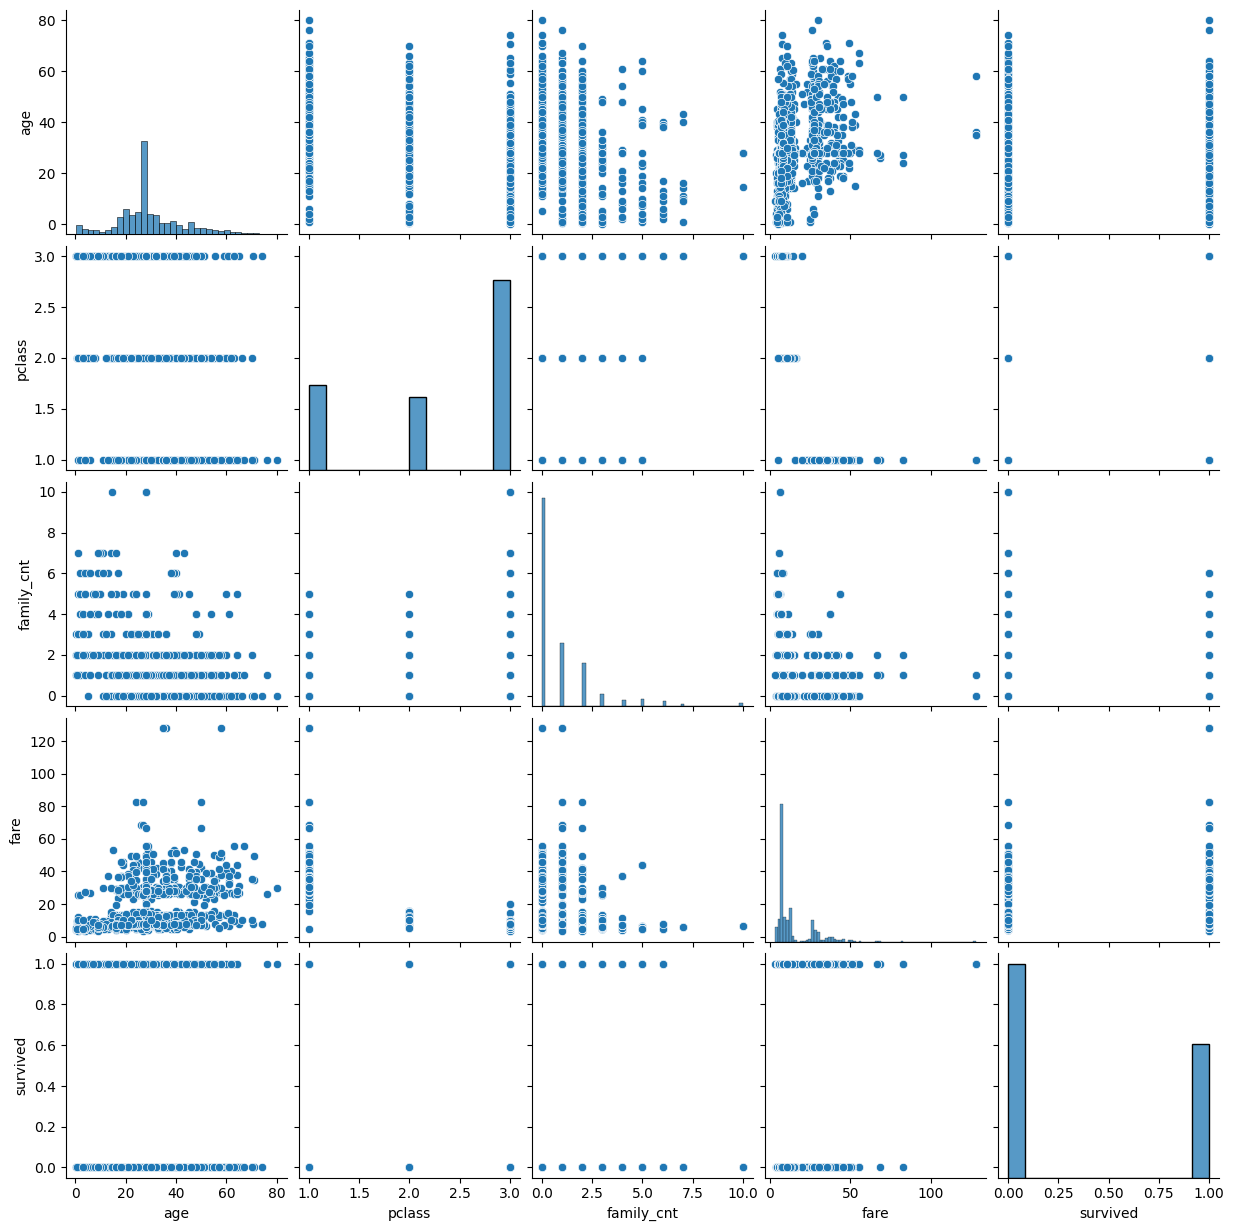

In [83]:
sns.pairplot(df)

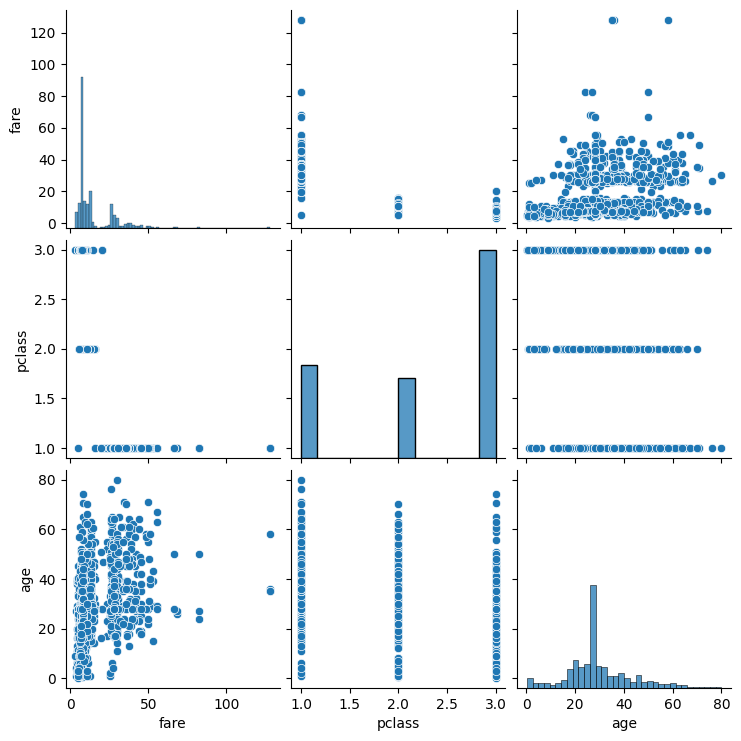

In [84]:
sns.pairplot(df[['fare','pclass','age']])

In [85]:
df.corr(numeric_only=True)

,age,pclass,family_cnt,fare,survived
age,1.000000,-0.378663,-0.193160,0.351995,-0.043844
pclass,-0.378663,1.000000,0.046349,-0.791188,-0.321205
family_cnt,-0.193160,0.046349,1.000000,-0.058819,0.023038
fare,0.351995,-0.791188,-0.058819,1.000000,0.261108
survived,-0.043844,-0.321205,0.023038,0.261108,1.000000
